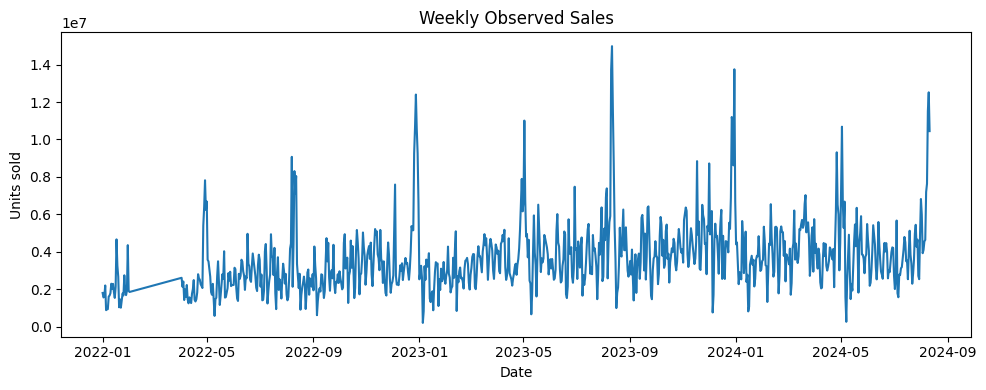

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned data
df = pd.read_excel("Sample_data_cleaned.xlsx")

# Assume columns: ["date", "product", "sales"]
df["date"] = pd.to_datetime(df["date"])

# Filter to a single product (anonymized)
df_p = df

plt.figure(figsize=(10, 4))
plt.plot(df_p["date"], df_p["sales"])
plt.title("Weekly Observed Sales")
plt.xlabel("Date")
plt.ylabel("Units sold")
plt.tight_layout()
plt.show()


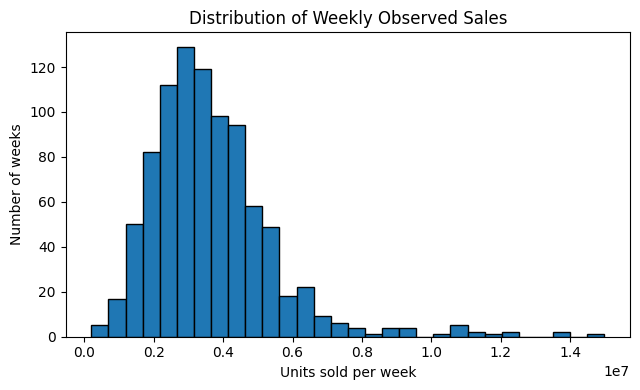

In [12]:
# Figure 3.2: Distribution of weekly aggregated sales

plt.figure(figsize=(6.5, 4))

plt.hist(
    df_p["sales"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Weekly Observed Sales")
plt.xlabel("Units sold per week")
plt.ylabel("Number of weeks")

plt.tight_layout()
plt.show()



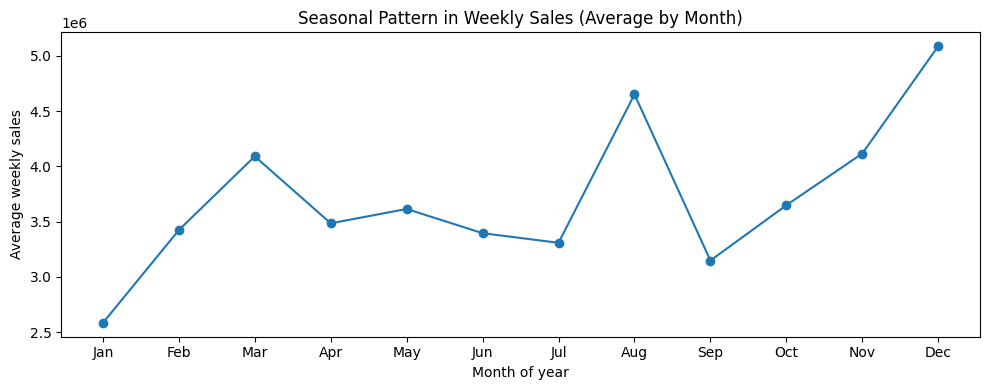

In [17]:
# Figure 3.3 (revised): Seasonality by calendar month

df_month = df_p.copy()
df_month["month"] = df_month["date"].dt.month

monthly_profile = (
    df_month
    .groupby("month")["sales"]
    .mean()
)

plt.figure(figsize=(10, 4))

plt.plot(
    monthly_profile.index,
    monthly_profile.values,
    marker="o",
    linestyle="-"
)

plt.xticks(
    ticks=range(1, 13),
    labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun",
            "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)

plt.title("Seasonal Pattern in Weekly Sales (Average by Month)")
plt.xlabel("Month of year")
plt.ylabel("Average weekly sales")

plt.tight_layout()
plt.show()


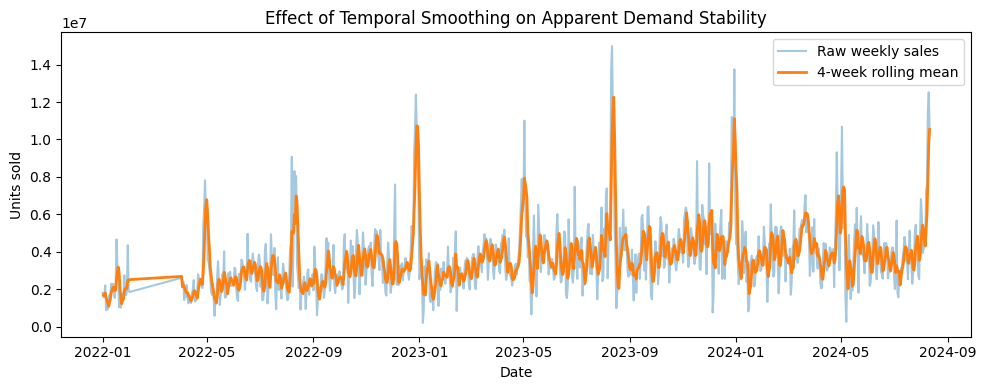

In [15]:
# Figure 3.4: Raw vs smoothed weekly series

window = 4  # 4-week rolling window (monthly-scale smoothing)
df_p["rolling_mean"] = df_p["sales"].rolling(window=window, min_periods=2).mean()

plt.figure(figsize=(10, 4))

plt.plot(
    df_p["date"],
    df_p["sales"],
    alpha=0.4,
    label="Raw weekly sales"
)

plt.plot(
    df_p["date"],
    df_p["rolling_mean"],
    linewidth=2,
    label=f"{window}-week rolling mean"
)

plt.title("Effect of Temporal Smoothing on Apparent Demand Stability")
plt.xlabel("Date")
plt.ylabel("Units sold")
plt.legend()

plt.tight_layout()
plt.show()
